In [3]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import glasbey
import seaborn as sns
import anndata as ad
import gc
from sklearn.preprocessing import QuantileTransformer
from tqdm import tqdm
from sklearn.neighbors import KDTree
from scipy.spatial import cKDTree

dir = '/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/PythonIMC'
sys.path.append(os.path.abspath(dir))
from pythonimc import assembling, compensation, convert_to_fcs, merging, plotting, scdata, mcd_preprocessing
from pythonimc import scneighbors, segmentation, tissuezones3, polarity, phenotyping

base_dir = '/Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis'

# Preprocessing

## MCD conversion

1. Convert MCD to TIFF: 
    - base_dir needs a folder "raw" with MCD files. 
    - choose HPF (hot pixel filter) threshold
2. Create panel from MCD files

In [ ]:
mcd_preprocessing.convert_mcd_to_tiff(base_dir, hpf=50)
mcd_preprocessing.create_panel_csv(base_dir)

## Project-specific adjustments

In [ ]:
# Swapped antibody names for Bi209 and Gd158
panel = pd.read_csv(os.path.join(base_dir, 'panel.csv'))
panel.loc[panel['channel'] == "Bi209", 'name'] = "Bi209_CD138"
panel.loc[panel['channel'] == "Bi209", 'marker'] = "CD138"
panel.loc[panel['channel'] == "Gd158", 'name'] = "Gd158_Neurofilament"
panel.loc[panel['channel'] == "Gd158", 'marker'] = "Neurofilament"
panel.to_csv(os.path.join(base_dir, 'panel.csv'), index=False)

In [ ]:
mcd_preprocessing.stitch_images(
    base_dir=base_dir,
    img_folder="img",
    img_top_name="20240808_OSCC_TMA_Tubingen_AB_A06.tiff",
    img_bottom_name="20240808_OSCC_TMA_Tubingen_AB_A06 - split.tiff",
    new_img_name="20240808_OSCC_TMA_Tubingen_AB_A06_new.tiff",
    visualize_channel_index=43,
)

mcd_preprocessing.archive_images(base_dir=base_dir, img_folder="img", 
                                 filenames=["20240808_OSCC_TMA_Tubingen_AB_A10old.tiff"])

# Image compensation

In [ ]:
import importlib
importlib.reload(compensation)
compensation.batch_compensate_images(base_dir, spillover_filename="spillovermatrix.csv", overwrite=False, backend="loky")

# Segmentation

## CellSAM

In [ ]:
segmentation.segment_imgs_cellsam(base_dir=base_dir, 
                          input_folder = 'img_comp', 
                          output_folder = "masks_muscle_cellsam",
                          nuclear_marker = '196Pt_Desmin')

## Mesmer

In [ ]:
segmentation.segment_imgs(base_dir=base_dir, 
                          input_folder = 'img_comp', 
                          output_folder = "masks_muscle",
                          markers = ['196Pt_Desmin'],
                          postprocess_kwargs = {
                                    'maxima_threshold': 0.075, # before 0.05
                                    'interior_threshold': 0.2, # before 0.15, 0.175
                                    'interior_smooth': 2,
                                    'small_objects_threshold': 60, # before 50
                                    'fill_holes_threshold': 30,
                                    'radius': 12
                                })

segmentation.segment_imgs(base_dir=base_dir, 
                          input_folder = 'img_comp', 
                          output_folder = "masks_vessel",
                          markers = ['160Gd_CD31'],
                          upper_bound=99.9,
                          postprocess_kwargs = {
                                    'maxima_threshold': 0.075, #before 0.05, 0.075, 0.15, 0.225
                                    'interior_threshold': 0.2, #before:0.15, 0.1,0.12, 0.09
                                    'interior_smooth': 2, #before 0.1, 1
                                    'small_objects_threshold': 15,
                                    'fill_holes_threshold': 15,
                                    'radius': 4 #before:10
                                })

segmentation.segment_imgs(base_dir=base_dir, 
                          input_folder = 'img_comp', 
                          output_folder = "masks_cells",
                          markers = ['161Dy_MPO', '162Dy_CD8a', '158Gd_CD138', '191Ir_DNA1', '193Ir_DNA2'], 
                          membrane_markers=['89Y_PanCK'],
                          image_mpp=0.8,
                          upper_bound=99,
                          postprocess_kwargs = {
                                'maxima_threshold': 0.075,
                                'interior_threshold': 0.05,
                                'interior_smooth': 2, 
                                'small_objects_threshold': 15,
                                'fill_holes_threshold': 15,
                                'radius': 2
                            })

## Merging masks

In [ ]:
merging.combine_masks(base_dir = base_dir,
                      masks_cells_folder= "masks_cells",
                      masks_muscle_folder = "masks_muscle",
                      masks_vessel_folder= "masks_vessel",
                      masks_merged_folder= "masks_merged",
                      size_threshold=20)

# Tissue zones

In [ ]:
from pythonimc import tissuezones3
import importlib
importlib.reload(tissuezones3)
tissuezones3.batch_generate_compartment_masks(base_dir=base_dir,
                                              tissue_channel=[0,1],
                                              tumor_channel=0,
                                              muscle_channel=46,
                                              overwrite=False,
                                              plot=False,
                                              img_folder= "img_comp",
                                              mask_folder= "masks_compartments")
tissuezones3.zonal_areas_table(base_dir)

# Single-cell data generation

In [ ]:
# scdata.create_intensities_files(base_dir, image_folder = 'img_comp', masks_folder = 'masks_merged', aggregation = 'mean')
#scdata.create_regionprops_files(base_dir, image_folder='img_comp', masks_folder='masks_merged', compartment_masks_folder='masks_compartments')
# scneighbors.create_neighbors_files(base_dir, masks_folder='masks_merged', neighbors_folder= "neighbors",neighborhood_type = "EUCLIDEAN_BORDER_DISTANCE", dmax=50.0, kmax=30)
polarity.create_polarity_files(base_dir=base_dir, img_dir = "img_comp", mask_dir = "masks_merged")

Skipping 20240908_OSCC_TMA_Tubingen_KL_K33.tiff: file already exists.
Skipping 20240821_OSCC_TMA_Tubingen_EF_F26.tiff: file already exists.
Skipping 20240808_OSCC_TMA_Tubingen_AB_A26.tiff: file already exists.
Skipping 20240817_OSCC_TMA_Tubingen_CD_D21.tiff: file already exists.
Skipping 20240817_OSCC_TMA_Tubingen_CD_D20.tiff: file already exists.
Skipping 20240908_OSCC_TMA_Tubingen_KL_L19.tiff: file already exists.
Skipping 20240821_OSCC_TMA_Tubingen_EF_E31.tiff: file already exists.
Skipping 20240817_OSCC_TMA_Tubingen_CD_C19.tiff: file already exists.
Skipping 20240826_OSCC_TMA_Tubingen_GH_H34.tiff: file already exists.
Skipping 20240905_OSCC_TMA_Tubingen_IJ_J16.tiff: file already exists.
Skipping 20240808_OSCC_TMA_Tubingen_AB_B05.tiff: file already exists.
Skipping 20240808_OSCC_TMA_Tubingen_AB_A07.tiff: file already exists.
Skipping 20240826_OSCC_TMA_Tubingen_GH_G10.tiff: file already exists.
Skipping 20240821_OSCC_TMA_Tubingen_EF_E33.tiff: file already exists.
Skipping 20240821_OS

# FCS file conversion

In [ ]:
convert_to_fcs.batch_convert_to_fcs(base_dir)

# Assembling dataset

Loading intensity data...


Reading intensities: 100%|██████████| 617/617 [1:09:35<00:00,  6.77s/it]


AnnData object created successfully!
(10002311, 49)
Loading regionprops data...


Reading regionprops: 100%|██████████| 617/617 [00:15<00:00, 40.91it/s]


Regionprops data merged successfully!
No polarity folder found at /Users/jeinhaus/Library/CloudStorage/GoogleDrive-jeinhaus@stanford.edu/Shared drives/Oral Immunology Projects/OSCC Recurrence/Clean_analysis/polarity, skipping polarity layer.
Cells assigned to background: 79605. Total cell count: 10002311.
Minimum cell area: 20
Maximum cell area: 10532

Top 10 largest cells by area:
  I25_10057: 10532.00
  T70_9383: 10005.00
  S15_12964: 9036.00
  I25_10218: 8865.00
  T70_9406: 8799.00
  T69_12435: 8492.00
  T70_9357: 8229.00
  T68_9094: 8134.00
  S61_9611: 8115.00
  H26_11598: 7736.00


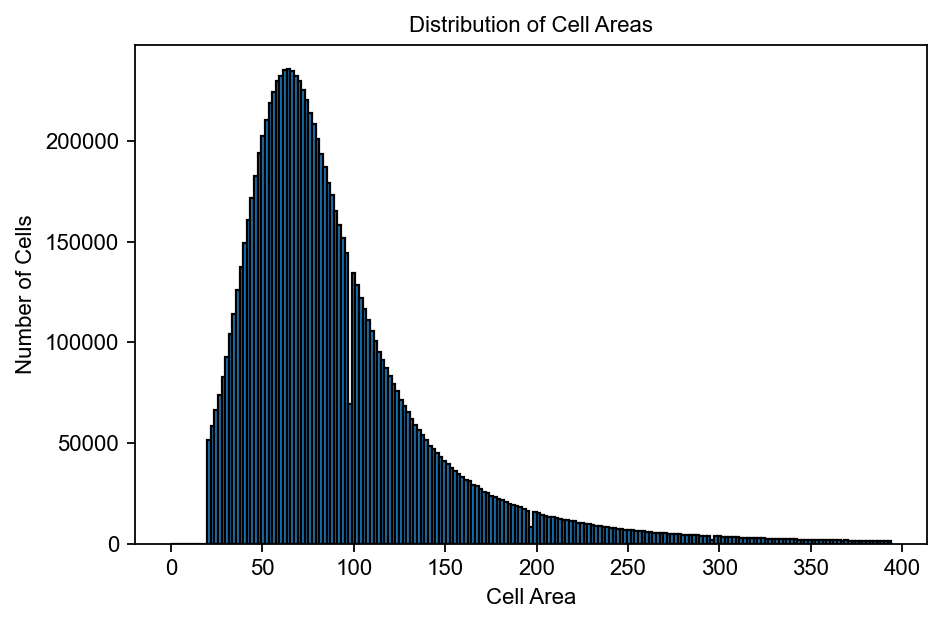


Top 10 cells with highest marker_sum:
  L14_20244: 182.70
  L14_20241: 182.19
  L14_20243: 172.24
  C33_1962: 163.90
  C33_24513: 162.17
  C33_2070: 159.45
  C33_2111: 158.59
  C35_925: 157.93
  C35_23024: 157.57
  C35_1216: 157.45


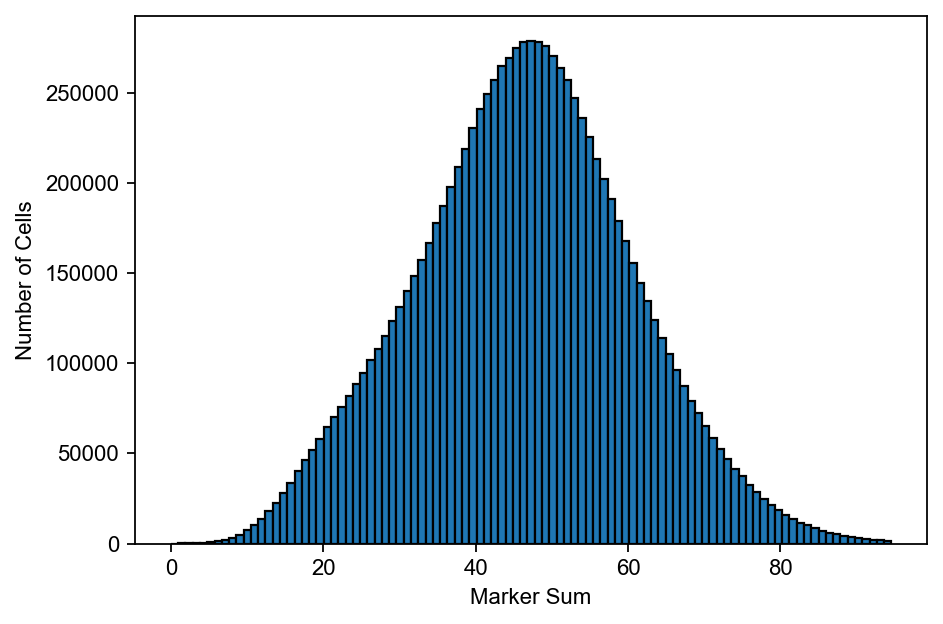

In [ ]:
data = assembling.assemble_anndata(base_dir, add_polarity=True)

data = assembling.add_metadata(data, base_dir=base_dir, metadata_files=['CasenumbersStanfordALL.csv','CasenumbersTubingenALL.csv'], merge_on_column="Image")
data = assembling.add_metadata(data, base_dir=base_dir, metadata_files=['zonal_areas_summary.csv'], merge_on_column="Image")
data.obs['Sector'] = data.obs['Zone'].str.split("_").str[1]
data = assembling.add_metadata(data, base_dir=base_dir, metadata_files=['Outcomes_Stanford.xlsx','Outcomes_Tubingen.xlsx'], merge_on_column="Casenumber")

assembling.anndata_qc(data)

data.write('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/data.h5ad')

In [ ]:
data = ad.read_h5ad('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/data.h5ad')

data.obs['Casenumber'] = data.obs['Casenumber'].str.upper()
data.obs["TMA"] = data.obs["Image"].str[0]

# Exclude Background and TMA controls
mask = ((data.obs['Zone'] != 'Background') & 
        (~data.obs['Casenumber'].str.contains('TONSIL|LIVER', na=False)))
data = data[mask].copy()

data.obs['Region'] = data.obs['Zone'].str.split("_").str[0]

# Add panel
panel = pd.read_csv(os.path.join(base_dir, "panel.csv"))
data.var['marker'] = panel['marker'].tolist()
data.var['channel_marker'] = panel['name'].tolist()
data.var.index = data.var['marker']
gc.collect()

44525

# Batch correction

In [ ]:
# Use arcsinh-transformed signal as input
X_raw = np.arcsinh(data.layers["counts"] - 1 ).astype(np.float32)
batches = data.obs["TMA"].values
markers = data.var_names

corrected = np.zeros_like(X_raw, dtype=np.float32)
unique_batches = np.unique(batches)

nq = 100  # number of quantiles (50–200 is fine)

for i, marker in enumerate(tqdm(markers, desc="Quantile normalizing per marker")):
    x = X_raw[:, i]
    corrected_marker = np.zeros_like(x)
    
    # --- 1. Fit reference distribution (global across all batches) ---
    ref_qt = QuantileTransformer(
        output_distribution="uniform",
        n_quantiles=nq,
        random_state=42,
        subsample=1_000_000
    )
    ref_qt.fit(x.reshape(-1, 1))
    ref_vals = ref_qt.quantiles_.ravel()  # flatten to 1-D
    
    # target quantile grid (0..1)
    q_grid = np.linspace(0, 1, nq)
    
    # --- 2. Align each batch to the reference ---
    for b in unique_batches:
        mask = batches == b
        xb = x[mask]
        
        if xb.size < 10:
            # Skip tiny batches
            corrected_marker[mask] = xb
            continue
        
        qt_batch = QuantileTransformer(
            output_distribution="uniform",
            n_quantiles=min(nq, xb.size),
            random_state=42,
            subsample=min(len(xb), 500_000)
        )
        qt_batch.fit(xb.reshape(-1, 1))
        
        xb_uniform = qt_batch.transform(xb.reshape(-1, 1)).ravel()
        corrected_marker[mask] = np.interp(xb_uniform, q_grid, ref_vals)
    
    corrected[:, i] = corrected_marker

# Save the corrected matrix back into the AnnData object
data.layers["corrected"] = corrected
del corrected
del X_raw

Quantile normalizing per marker: 100%|██████████| 49/49 [04:22<00:00,  5.36s/it]


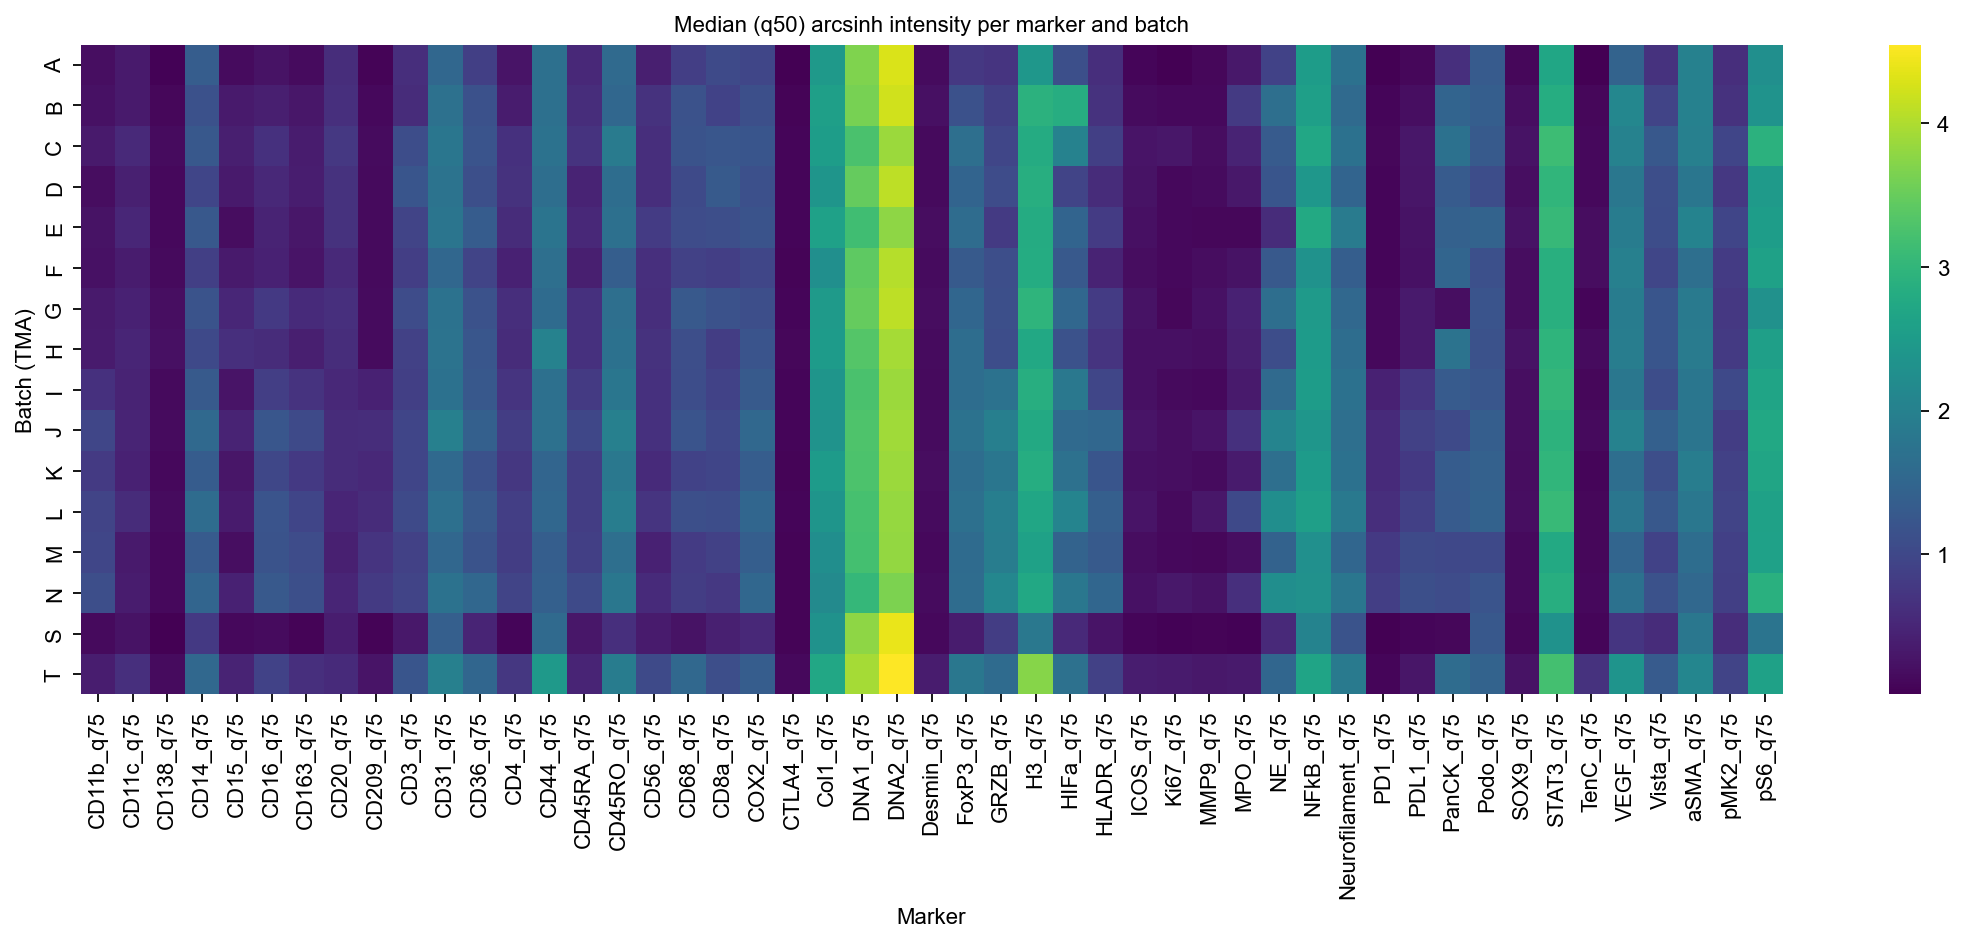

In [ ]:
X = pd.DataFrame(
    np.arcsinh(data.layers["counts"]).astype(np.float32),
    columns=data.var_names,
    index=data.obs_names
)

batches = data.obs["TMA"]

# --- 2. Compute quantiles per batch and marker ---
quantiles = [0.05, 0.25, 0.5, 0.75, 0.95]

# Join the batch info
X["TMA"] = batches.values

# Compute quantiles per batch and marker
quantile_df = (
    X.groupby("TMA")
    .quantile(quantiles)
    .reset_index()
)

# The resulting index has two levels: 'TMA' and the quantile level
# We'll pivot to have markers × quantiles per batch
quantile_df = quantile_df.melt(
    id_vars=["TMA", "level_1"],
    var_name="Marker",
    value_name="Intensity"
)
quantile_df["Quantile"] = quantile_df["level_1"].map(lambda q: f"q{int(q*100)}")
quantile_df.drop(columns="level_1", inplace=True)

# --- 3. Optional: Pivot into a wide table for heatmap ---
pivot_df = (
    quantile_df.pivot_table(
        index="TMA",
        columns=["Marker", "Quantile"],
        values="Intensity"
    )
)

# Simplify multiindex columns for visualization
pivot_df.columns = [f"{marker}_{quantile}" for marker, quantile in pivot_df.columns]

# --- 4. Visualize median (q50) intensities per batch ---
median_cols = [c for c in pivot_df.columns if "_q75" in c]
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_df[median_cols], cmap="viridis")
plt.title("Median (q50) arcsinh intensity per marker and batch")
plt.xlabel("Marker")
plt.ylabel("Batch (TMA)")
plt.tight_layout()
plt.show()

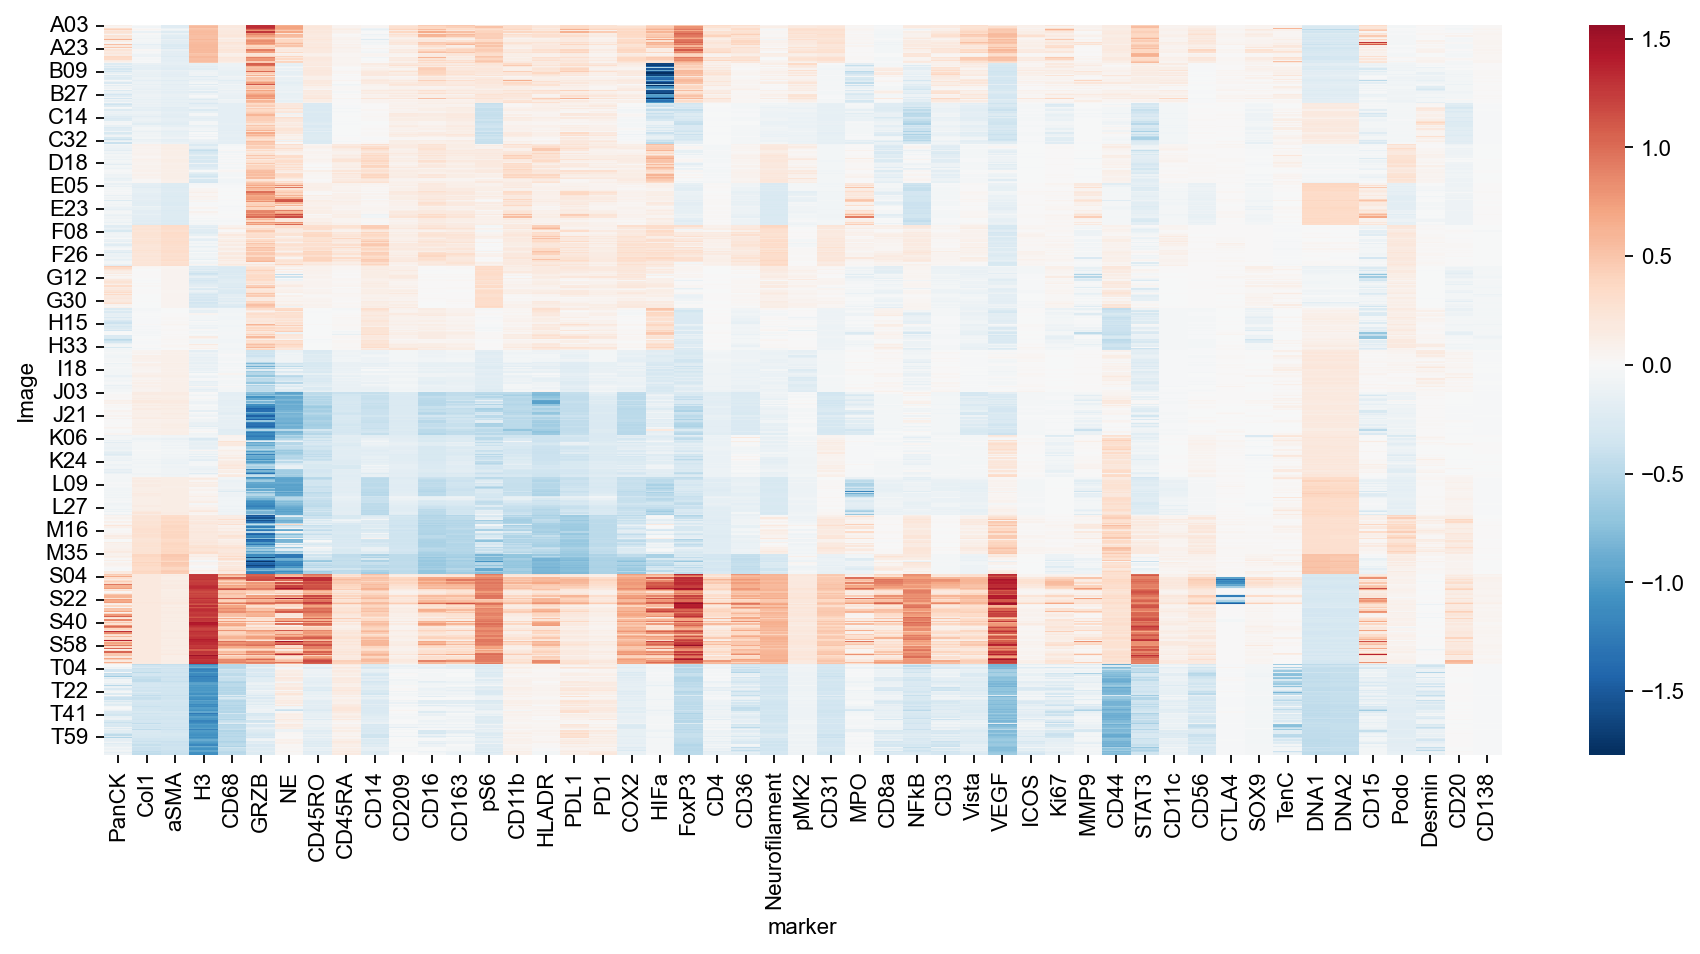

In [ ]:
counts = np.arcsinh(data.layers["counts"] - 1)
corrected = data.layers["corrected"]

# Difference matrix
diff = corrected - counts  # shape (cells, markers)
df_diff = pd.DataFrame(diff, index=data.obs.index, columns=data.var.index)

# add Image column for grouping
df_diff["Image"] = data.obs["Image"].values

heatmap_data = df_diff.groupby("Image").mean()
heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(14,6))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",        # diverging colormap
    center=0
)
plt.show()

# Phenotyping

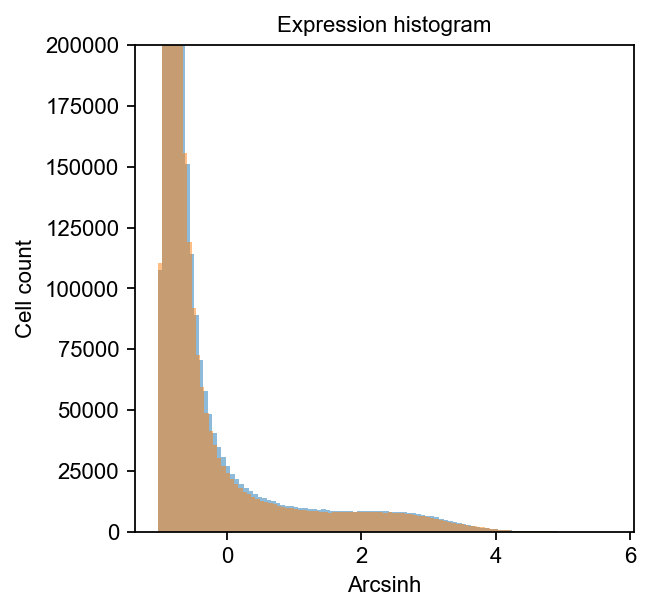

In [ ]:
cd68_idx = data.var.index.get_loc("CD8a")
mask = data.obs['Region'] == "Tumor"
cd68_vals = np.arcsinh(data.layers['counts'][:, cd68_idx] - 1)[mask]
cd68_vals_c = data.layers['corrected'][:, cd68_idx][mask]

plt.hist(cd68_vals / cd68_vals.std(), bins=100, alpha=0.5)
plt.hist(cd68_vals_c / cd68_vals_c.std(), bins=100, alpha=0.5)
plt.ylim(0, 200_000)
plt.xlabel("Arcsinh")
plt.ylabel("Cell count")
plt.title("Expression histogram")
plt.show()

## Tumor subsetting

Setting: 

lr=0.0005, prior_std=0.3, max_epochs=400, patience=8, polarity=False, 113 epochs, 

Results: 

TumorNonproliferating    0.413678
TumorSOX9+               0.121837
TumorpMK2+               0.116865
CD8Tcells                0.110369
Granulocytes             0.072233
TumorKi67+               0.064336
TumorKi67+SOX9+          0.054136
CD4Tcells                0.030836
Bcells                   0.005253

In [ ]:
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_tumor_new.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="Image",
                      filter="Region",
                      filter_for="Tumor",
                      unassigned_label="TumorNonproliferating",
                      phenotype_level="Celltype",
                      prior_std=0.3,
                      polarity=False)

Subsetted AnnData to 2708206 cells.
Filtered for Tumor from Region
Running SCYAN on 2708206 cells...


[INFO] (scyan.model) Initialized Scyan model with N=2708206 cells, P=16 populations and M=19 markers.
   ├── Covariates: Image
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       Image
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.3
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 158 K  | train
-----------------------------------------------
158 K     Trainable params
0         Non-trainable params
158 K     Total params
0.635     Total estimated model params size (MB)
243       Modules in train mode
0         Modu

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/331 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Celltype' (subset):
 Celltype
TumorNonproliferating    0.413837
TumorSOX9+               0.160450
CD8Tcells                0.104672
TumorKi67+               0.083631
Granulocytes             0.081718
TumorKi67+SOX9+          0.070868
CD4Tcells                0.022565
Monocytes                0.018507
TumorpMK2+               0.017804
Macrophages              0.009733
Bcells                   0.006731
Capillary                0.005319
SM                       0.003606
NaN                      0.000392
NKcells                  0.000093
Nerve                    0.000071
Arteriole                0.000003
Name: proportion, dtype: float64

Absolute counts by 'Celltype' (subset):
 Celltype
TumorNonproliferating    1120755
TumorSOX9+                434533
CD8Tcells                 283472
TumorKi67+                226491
Granulocytes              221308
TumorKi67+SOX9+           191924
CD4Tcells                  61112
Monocytes                  50122
TumorpM

AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'corrected'

## Stroma subsetting

Settings: 

lr=0.0005, prior_std=0.4, max_epochs=400, patience=8, polarity=False, 131 epochs, 

Results:
Other                    0.187321
CD8Tcells                0.159827
CD4Tcells                0.123115
Granulocytes             0.089797
Capillary                0.087337
Bcells                   0.066582
Macrophages              0.055866
Arteriole                0.053131
Monocytes                0.046908
TumorNonproliferating    0.041357
FibroblastsTenC+         0.030246
SM                       0.029278
Lymphatics               0.026701
Nerve                    0.001860

In [ ]:
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_stroma.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="TMA",
                      filter="Region",
                      filter_for="Stroma",
                      unassigned_label="Other",
                      phenotype_level="Celltype",
                      prior_std=0.4,
                      polarity=False)

Subsetted AnnData to 5620148 cells.
Filtered for Stroma from Region
Running SCYAN on 5620148 cells...


[INFO] (scyan.model) Initialized Scyan model with N=5620148 cells, P=15 populations and M=20 markers.
   ├── Covariates: TMA
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       TMA
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.4
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 35.9 K | train
-----------------------------------------------
35.9 K    Trainable params
0         Non-trainable params
35.9 K    Total params
0.144     Total estimated model params size (MB)
243       Modules in train mode
0         Modules 

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/687 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Celltype' (subset):
 Celltype
CD8Tcells                0.169927
Other                    0.152867
CD4Tcells                0.120893
Granulocytes             0.117968
Capillary                0.097818
Bcells                   0.068640
Macrophages              0.060233
TumorNonproliferating    0.057870
Arteriole                0.053014
Monocytes                0.036906
FibroblastsTenC+         0.028601
Lymphatics               0.017332
SM                       0.015792
Nerve                    0.001591
NaN                      0.000536
NKcells                  0.000013
Name: proportion, dtype: float64

Absolute counts by 'Celltype' (subset):
 Celltype
CD8Tcells                955013
Other                    859136
CD4Tcells                679439
Granulocytes             662995
Capillary                549752
Bcells                   385766
Macrophages              338516
TumorNonproliferating    325236
Arteriole                297945
Monocytes        

AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'corrected'

## Muscle subsetting

Settings: 

lr=0.0005, prior_std=0.3, max_epochs=400, patience=8, polarity=True, 60 epoches

Results:

SM              0.848713
Capillary       0.074307
Granulocytes    0.025103
Macrophages     0.014928
Bcells          0.010080
Monocytes       0.007407

In [ ]:
import importlib
importlib.reload(phenotyping)
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_muscle_new.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="Image", 
                      filter="Region",
                      filter_for="Muscle",
                      unassigned_label="Other",
                      phenotype_level="Celltype",
                      prior_std=0.26,
                      polarity=False)

Subsetted AnnData to 728480 cells.
Filtered for Muscle from Region
Running SCYAN on 728480 cells...


[INFO] (scyan.model) Initialized Scyan model with N=728480 cells, P=14 populations and M=17 markers.
   ├── Covariates: Image
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       Image
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.26
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 145 K  | train
-----------------------------------------------
145 K     Trainable params
0         Non-trainable params
145 K     Total params
0.582     Total estimated model params size (MB)
243       Modules in train mode
0         Modu

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/89 [00:00<?, ?it/s]

[WARNING] (scyan.model) 2 population(s) were not predicted. It may be due to:
  - Errors in the knowledge table (see https://mics-lab.github.io/scyan/advice/#advice-for-the-creation-of-the-table)
  - The model hyperparameters choice (see https://mics-lab.github.io/scyan/advanced/parameters/)
  - Or maybe these populations are really absent from this dataset.


Model run finished!

Proportions by 'Celltype' (subset):
 Celltype
SM                       0.722156
Capillary                0.098498
CD8Tcells                0.066652
Granulocytes             0.034495
TumorNonproliferating    0.033608
Arteriole                0.020587
Bcells                   0.017836
Monocytes                0.002383
Lymphatics               0.001914
Macrophages              0.000879
CD4Tcells                0.000648
FibroblastsTenC+         0.000180
NaN                      0.000165
NKcells                  0.000000
Nerve                    0.000000
Name: proportion, dtype: float64

Absolute counts by 'Celltype' (subset):
 Celltype
SM                       526076
Capillary                 71754
CD8Tcells                 48555
Granulocytes              25129
TumorNonproliferating     24483
Arteriole                 14997
Bcells                    12993
Monocytes                  1736
Lymphatics                 1394
Macrophages                 640
CD4Tcells          

AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'counts', 'corrected'

In [ ]:
for col in data.obs.select_dtypes(include=["datetime64[ns]"]).columns:
    data.obs[col] = data.obs[col].dt.strftime("%Y-%m-%d")
data.write('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/11222025_annotdata.h5ad')

## CD4 T cell subsetting

Settings: prior_std=0.4, lr=0.00001, polarity=True, max_epochs=400, patience=8, 150 epochs

Results: 

CD4Tmemory    0.751599
CD4Tfh        0.109102
CD4Tnaive     0.100423
CD4Tregs      0.038858

In [ ]:
data = ad.read_h5ad('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/11222025_annotdata.h5ad')

In [ ]:
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_CD4Tcells.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="TMA", 
                      filter="Celltype",
                      filter_for="CD4Tcells",
                      unassigned_label="CD4Tmemory",
                      phenotype_level="Subtype",
                      prior_std=0.3,
                      polarity=False)

Subsetted AnnData to 741023 cells.
Filtered for CD4Tcells from Celltype
Running SCYAN on 741023 cells...


[INFO] (scyan.model) Initialized Scyan model with N=741023 cells, P=4 populations and M=5 markers.
   ├── Covariates: TMA
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       TMA
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.3
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 29.0 K | train
-----------------------------------------------
29.0 K    Trainable params
0         Non-trainable params
29.0 K    Total params
0.116     Total estimated model params size (MB)
243       Modules in train mode
0         Modules in 

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/91 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Subtype' (subset):
 Subtype
CD4Tmemory    0.678521
CD4Tregs      0.126714
CD4Tnaive     0.104866
CD4Tfh        0.089895
NaN           0.000004
Name: proportion, dtype: float64

Absolute counts by 'Subtype' (subset):
 Subtype
CD4Tmemory    502800
CD4Tregs       93898
CD4Tnaive      77708
CD4Tfh         66614
NaN                3
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'corrected', 'counts'

## CD8 T cell subsetting

Settings: lr=0.0005, prior_std=0.3, polarity=True, 32 epochs

Results:

CD8Tmemory     0.481928
CD8Teff        0.342798
CD8Tnaive      0.141382
CD8Ttrmlike    0.033469

In [ ]:
import importlib
importlib.reload(phenotyping)
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_CD8Tcells.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="Image", 
                      filter="Celltype",
                      filter_for="CD8Tcells",
                      unassigned_label="CD8Tmemory",
                      phenotype_level="Subtype",
                      prior_std=0.3,
                      polarity=False)

Subsetted AnnData to 1287040 cells.
Filtered for CD8Tcells from Celltype
Running SCYAN on 1287040 cells...


[INFO] (scyan.model) Initialized Scyan model with N=1287040 cells, P=4 populations and M=5 markers.
   ├── Covariates: Image
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       Image
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.3
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 153 K  | train
-----------------------------------------------
153 K     Trainable params
0         Non-trainable params
153 K     Total params
0.614     Total estimated model params size (MB)
243       Modules in train mode
0         Module

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/158 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Subtype' (subset):
 Subtype
CD8Tmemory     0.452029
CD8Teff        0.345024
CD8Tnaive      0.158953
CD8Ttrmlike    0.043753
NaN            0.000241
Name: proportion, dtype: float64

Absolute counts by 'Subtype' (subset):
 Subtype
CD8Tmemory     581779
CD8Teff        444060
CD8Tnaive      204579
CD8Ttrmlike     56312
NaN               310
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'corrected', 'counts'

## MacroMono subsetting

In [ ]:
phenotyping.run_scyan(adata=data, 
                      knowledgetable="knowledgetable_MacroMono.xlsx", 
                      knowledgetable_dir="knowledgetables", 
                      base_dir=base_dir, 
                      batch_key="TMA", 
                      filter="Celltype",
                      filter_for=["Macrophages", "Monocytes"],
                      unassigned_label="M1Macro",
                      phenotype_level="Subtype",
                      prior_std=0.5,
                      polarity=False)

Subsetted AnnData to 624791 cells.
Filtered for ['Macrophages', 'Monocytes'] from Celltype
Running SCYAN on 624791 cells...


[INFO] (scyan.model) Initialized Scyan model with N=624791 cells, P=5 populations and M=7 markers.
   ├── Covariates: TMA
   ├── No continuum-marker provided
   └── Batch correction mode: True
[INFO] (scyan.model) Training scyan with the following hyperparameters:
"batch_key":       TMA
"batch_size":      8192
"hidden_size":     16
"lr":              0.0005
"max_samples":     200000
"modulo_temp":     3
"n_hidden_layers": 6
"n_layers":        7
"prior_std":       0.5
"temperature":     0.5
"warm_up":         (0.35, 4)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type        | Params | Mode 
-----------------------------------------------
0 | module | ScyanModule | 29.9 K | train
-----------------------------------------------
29.9 K    Trainable params
0         Non-trainable params
29.9 K    Total params
0.120     Total estimated model params size (MB)
243       Modules in train mode
0         Modules in 

Training: |          | 0/? [00:00<?, ?it/s]

[INFO] (scyan.model) Ended warm up epochs
[INFO] (scyan.model) Successfully ended training.


DataLoader:   0%|          | 0/77 [00:00<?, ?it/s]

Model run finished!

Proportions by 'Subtype' (subset):
 Subtype
M1Macro          0.597254
M2Macro          0.266961
M2MacroCD209+    0.100614
DCs              0.021690
Monocytes        0.013478
NaN              0.000002
Name: proportion, dtype: float64

Absolute counts by 'Subtype' (subset):
 Subtype
M1Macro          373159
M2Macro          166795
M2MacroCD209+     62863
DCs               13552
Monocytes          8421
NaN                   1
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 9056834 × 49
    obs: 'Object', 'Image', 'Area', 'Centroid-0', 'Centroid-1', 'Axis_major_length', 'Axis_minor_length', 'Eccentricity', 'Orientation', 'Zone', 'Casenumber', 'Blocknumber', 'Stromacore', 'Stromaborder', 'Tumorborder', 'Tumorcore', 'TMA', 'Region', 'Celltype', 'Subtype'
    var: 'channel_marker', 'marker', 'channel'
    layers: 'corrected', 'counts'

In [ ]:
# Ensure both are categorical
data.obs["Celltype"] = data.obs["Celltype"].astype("category")
data.obs["Subtype"] = data.obs["Subtype"].astype("category")

# Add any missing categories from Celltype into Subtype
missing_cats = [cat for cat in data.obs["Celltype"].cat.categories
                if cat not in data.obs["Subtype"].cat.categories]
if missing_cats:
    data.obs["Subtype"] = data.obs["Subtype"].cat.add_categories(missing_cats)

# Fill only missing values in Subtype with string values from Celltype
mask = data.obs["Subtype"].isna()
data.obs.loc[mask, "Subtype"] = data.obs.loc[mask, "Celltype"].astype(str)

# Clean unused categories
data.obs["Subtype"] = data.obs["Subtype"].astype("category")
data.obs["Subtype"] = data.obs["Subtype"].cat.remove_unused_categories()

In [ ]:
data.write('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/11242025_annotdata.h5ad')

# Distance to the tumorborder

In [ ]:
data = tissuezones3.calculate_distance_to_tumor(base_dir, data, columnname='Distance_to_tumor', overwrite=False)

Calculating distance to tumor: 0it [00:00, ?it/s]


# Closest distance to celltype

In [ ]:
# Coordinates
coords = data.obs[['Centroid-0', 'Centroid-1']].values  # shape (n_cells, 2)
celltypes = data.obs['Subtype'].values
targets = data.obs['Subtype'].unique()
images = data.obs['Image'].unique()

for t in tqdm(targets):
    target_coords = coords[celltypes == t]

    dist_to_target = np.full(len(data), np.nan)  # default NaN

    for img in tqdm(images):
        mask_img = data.obs["Image"] == img
        mask_target = mask_img & (celltypes == t)
        
        if mask_target.sum() < 2:
            continue  # no target cells in this image
        else:
            target_coords = coords[mask_target]
            tree = KDTree(target_coords)
            # query all cells in this image
            distances, _ = tree.query(coords[mask_img], k=2)
            dist_to_target[mask_img] = distances[:,1]

    data.obs[f'Dist_to_{t}'] = dist_to_target

# Neighborhood analysis

In [ ]:
def fast_neighbor_subtypes_for_image(
        adata,
        image_id,
        neighbors_dir,
        max_neighbors=10,
        max_distance=20,
    ):
    csv_path = None
    suffix = f"_{image_id}.csv"
    for f in os.listdir(neighbors_dir):
        if f.endswith(suffix):
            csv_path = os.path.join(neighbors_dir, f)
            break
    if csv_path is None:
        raise FileNotFoundError(f"No neighbor file ending with {suffix}")
    df = pd.read_csv(csv_path, usecols=["Object", "Neighbor", "Distance"])
    if max_distance is not None:
        df = df[df["Distance"] <= max_distance]

    if df.empty:
        return pd.DataFrame({"NeighborSubtypes": []})

    prefix = image_id + "_"
    df["Object_id"] = prefix + df["Object"].astype(str)
    df["Neighbor_id"] = prefix + df["Neighbor"].astype(str)

    img_mask = (adata.obs["Image"] == image_id)
    valid_ids = set(adata.obs_names[img_mask])

    df = df[df.Object_id.isin(valid_ids) & df.Neighbor_id.isin(valid_ids)]

    if df.empty:
        return pd.DataFrame({"NeighborSubtypes": []})

    subtype_map = adata.obs["Subtype"].to_dict()

    df.sort_values(["Object_id", "Distance"], inplace=True)

    df = df.groupby("Object_id", sort=False).head(max_neighbors)

    df["NeighborSubtype"] = df["Neighbor_id"].astype(str).map(subtype_map)

    out = (
        df.groupby("Object_id")["NeighborSubtype"]
          .apply(lambda x: x.tolist())
          .to_frame("NeighborSubtypes")
    )

    return out


def neighbor_list_to_proportions_fast(neighbor_df, adata):
    """
    Super-fast vectorized computation of neighbor subtype proportions.
    No Python loops. Works for hundreds of thousands of cells.
    """
    # All subtypes to include as columns
    all_subtypes = adata.obs["Subtype"].unique()

    # Step 1 — expand lists into rows (explode)
    exploded = neighbor_df["NeighborSubtypes"].explode()

    # Step 2 — count occurrences per (cell, subtype)
    counts = exploded.groupby([exploded.index, exploded]).size()

    # Step 3 — convert to wide matrix (one row per cell, one column per subtype)
    wide = counts.unstack(fill_value=0).reindex(columns=all_subtypes, fill_value=0)

    # Step 4 — divide by row sums (proportions)
    proportions = wide.div(wide.sum(axis=1), axis=0).fillna(0)

    # Step 5 — assign into adata.obs (fastest method)
    for subtype in all_subtypes:
        colname = f"Neighboring_{subtype}"
        adata.obs[colname] = 0.0  # ensure column exists
        if subtype in proportions.columns:
            adata.obs.loc[proportions.index, colname] = proportions[subtype]

    return adata


def process_all_image_neighbors(adata, neighbors_dir, max_neighbors=10, max_distance=20):

    all_dfs = []
    images = adata.obs["Image"].unique()
    for img in tqdm(images):
        df_img = fast_neighbor_subtypes_for_image(
            adata,
            image_id=img,
            neighbors_dir=neighbors_dir,
            max_neighbors=max_neighbors,
            max_distance=max_distance,
        )
        all_dfs.append(df_img)
    result = pd.concat(all_dfs)

    adata = neighbor_list_to_proportions_fast(result, adata)

    return adata

data = process_all_image_neighbors(data, os.path.join(base_dir, "neighbors"), max_neighbors=10, max_distance=20)

100%|██████████| 572/572 [1:56:06<00:00, 12.18s/it]


In [ ]:
for col in data.obs.columns:
    if pd.api.types.is_datetime64_any_dtype(data.obs[col]):
        data.obs[col] = data.obs[col].astype(str)
data.write('/Users/jeinhaus/Documents/03 Stanford data/OSCC Recurrence/12012025_annotdata.h5ad')